In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import utils

utils.set_matplotlib_style()

## Sweep 1

In [6]:
RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
MODELS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

### Plot Heatmaps

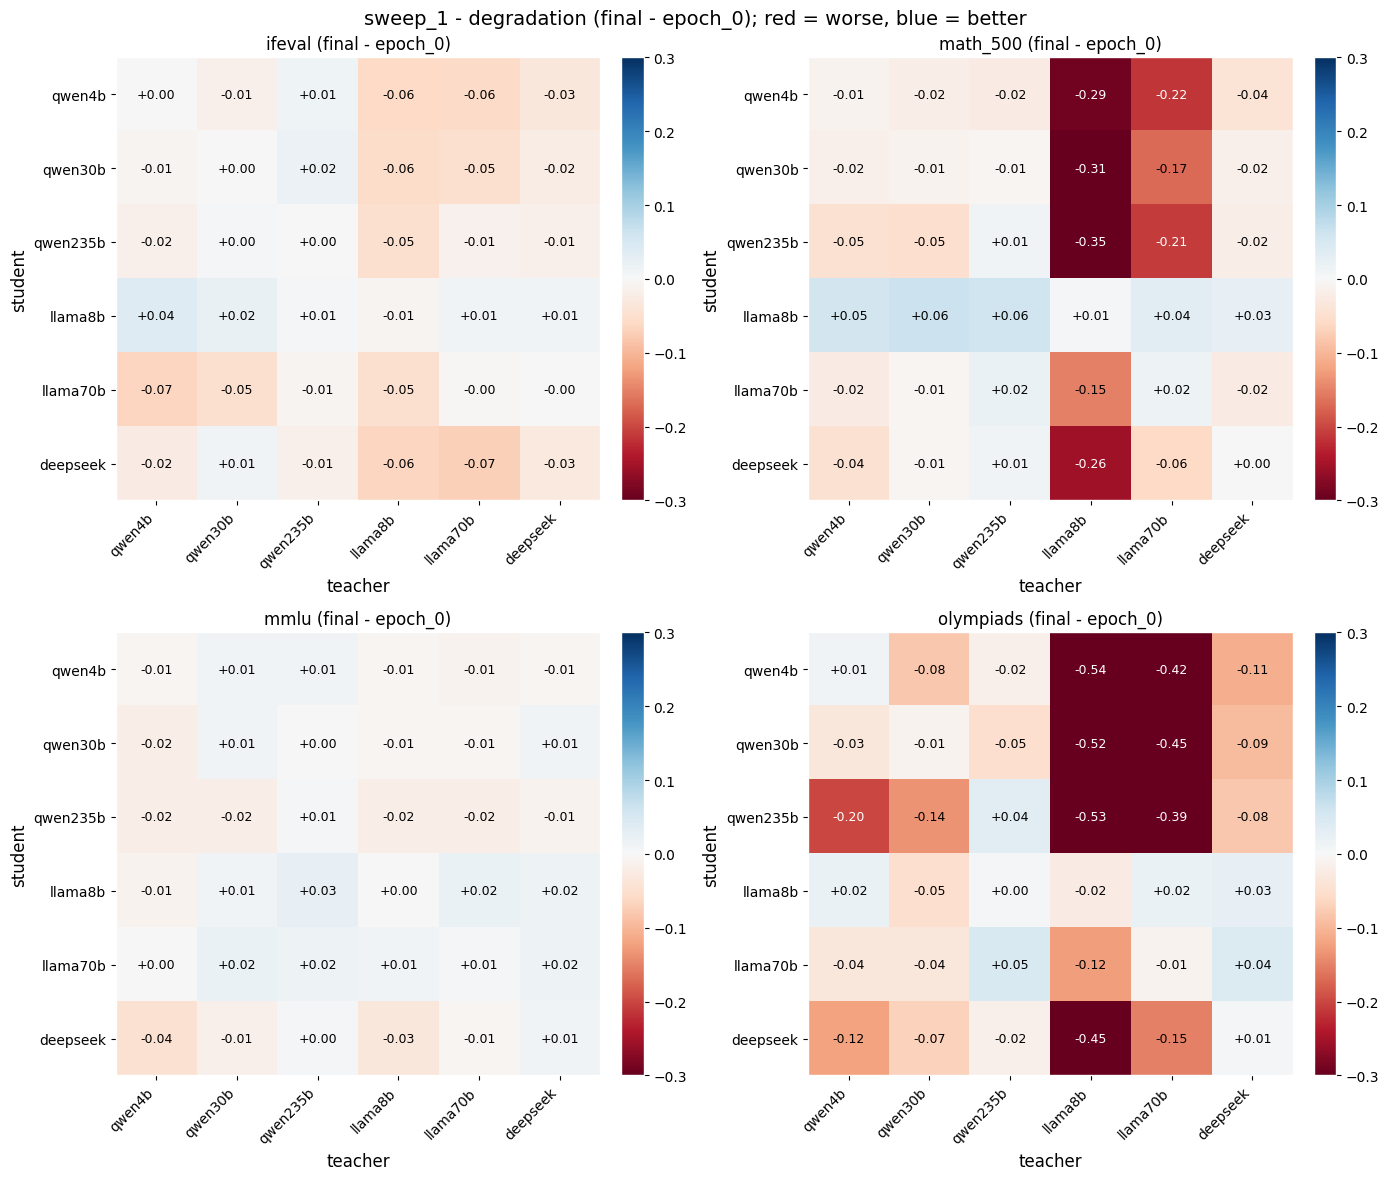

: 

In [ ]:
def load_degradation(eval_name, student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


VLIM = 0.3

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([[load_degradation(eval_name, s, t) for t in MODELS] for s in MODELS])
    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(MODELS)), MODELS, rotation=45, ha='right')
    ax.set_yticks(range(len(MODELS)), MODELS)
    ax.set_xlabel('teacher')
    ax.set_ylabel('student')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i in range(len(MODELS)):
        for j in range(len(MODELS)):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('sweep_1 - degradation (final - epoch_0); red = worse, blue = better')
fig.tight_layout()
plt.show()

### Loss Curves + Olympiads Degradation

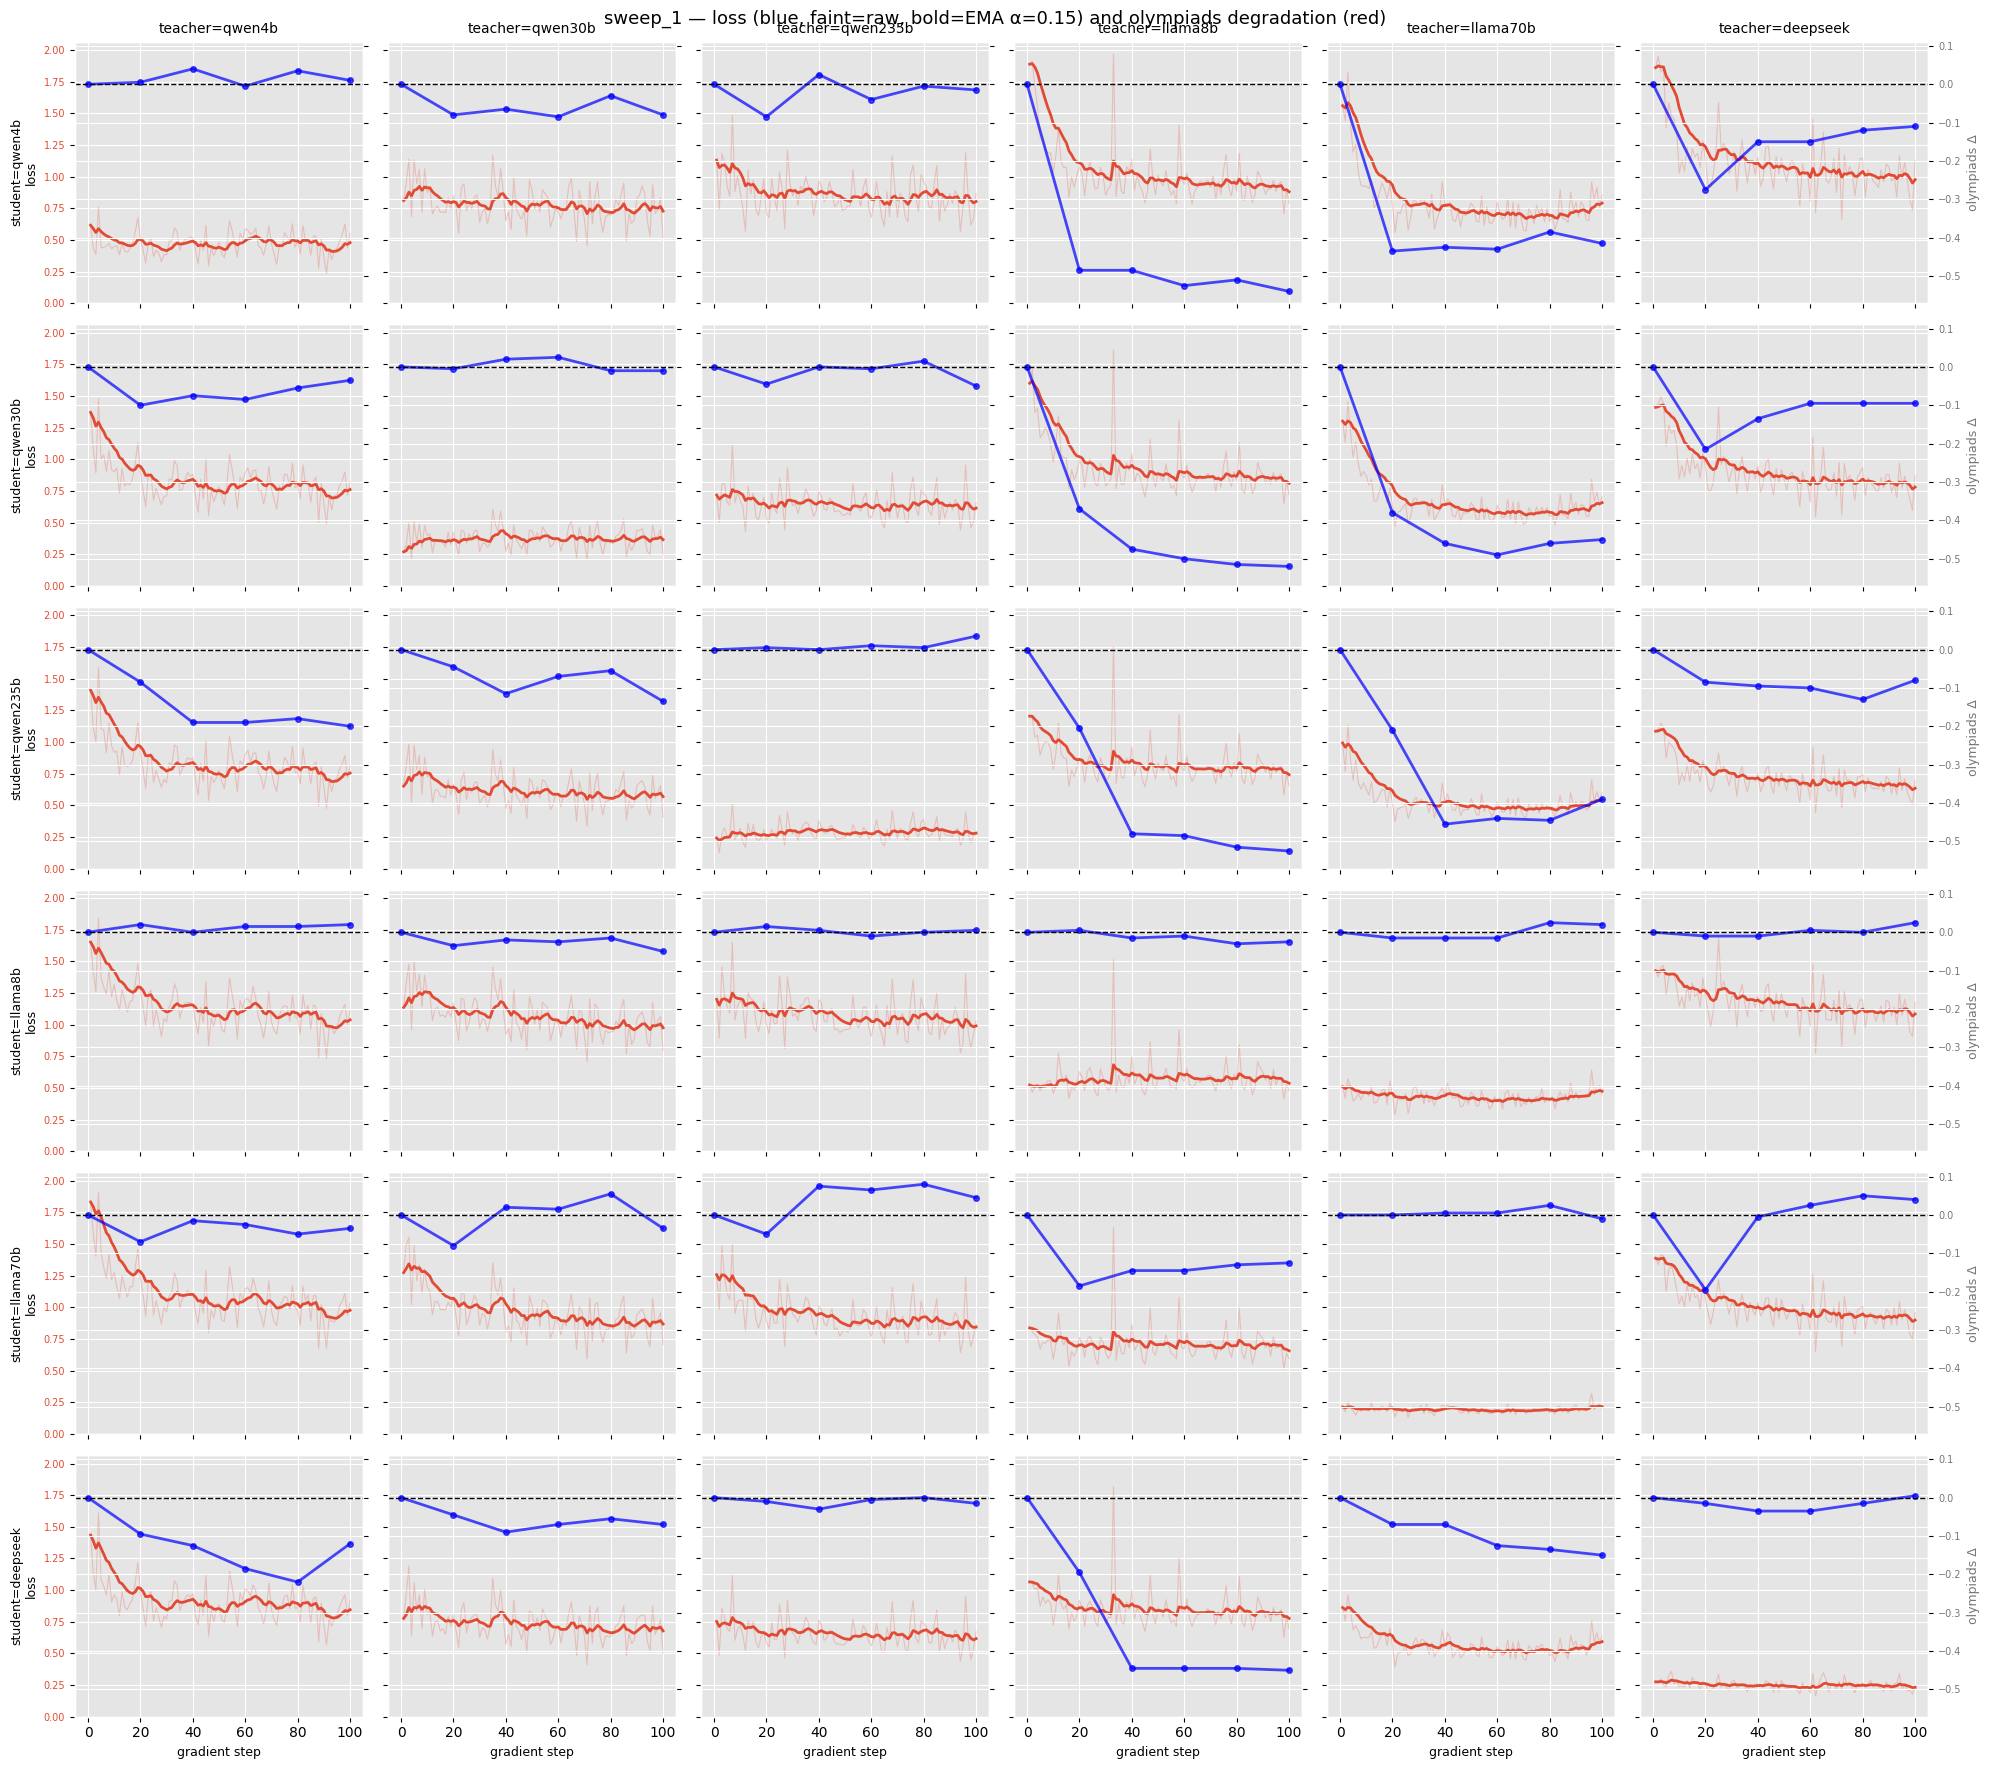

In [14]:
def load_losses(student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'losses.json'
    if not path.exists():
        return None
    return np.array(json.loads(path.read_text()))


def load_olympiads_curve(student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return None
    return np.array(json.loads(path.read_text())['olympiads'])


def ema(xs, alpha=0.15):
    out = np.empty_like(xs, dtype=float)
    out[0] = xs[0]
    for i in range(1, len(xs)):
        out[i] = alpha * xs[i] + (1 - alpha) * out[i - 1]
    return out


# Pre-compute global y-limits across all (student, teacher) pairs
all_losses, all_degs = [], []
for student in MODELS:
    for teacher in MODELS:
        losses = load_losses(student, teacher)
        olymp = load_olympiads_curve(student, teacher)
        if losses is not None:
            all_losses.append(losses)
        if olymp is not None:
            all_degs.append(olymp - olymp[0])

loss_max = max(l.max() for l in all_losses)
deg_min = min(d.min() for d in all_degs)
deg_max = max(d.max() for d in all_degs)
deg_pad = 0.05 * (deg_max - deg_min)
loss_ylim = (0, loss_max * 1.05)
deg_ylim = (deg_min - deg_pad, deg_max + deg_pad)


fig, axes = plt.subplots(len(MODELS), len(MODELS), figsize=(20, 18), sharex=True, sharey=True)
twin_axes = np.empty_like(axes)
for i, student in enumerate(MODELS):
    for j, teacher in enumerate(MODELS):
        ax = axes[i, j]
        ax2 = ax.twinx()
        twin_axes[i, j] = ax2

        losses = load_losses(student, teacher)
        olymp = load_olympiads_curve(student, teacher)

        if losses is None or olymp is None:
            ax.set_facecolor('#f5f5f5')
        else:
            steps = np.arange(1, len(losses) + 1)
            ax.plot(steps, losses, color='C0', alpha=0.25, linewidth=0.8)
            ax.plot(steps, ema(losses, alpha=0.15), color='C0', linewidth=2.0, label='loss (EMA)')

            olymp_steps = np.linspace(0, len(losses), len(olymp))
            degradation = olymp - olymp[0]
            ax2.plot(olymp_steps, degradation, color='blue', linewidth=2.0, marker='o', markersize=4, label='olympiads Δ', alpha = 0.7)
            ax2.axhline(y = 0, color='black', linewidth=1.0, linestyle='--', alpha=1.0)

        ax.set_ylim(loss_ylim)
        ax2.set_ylim(deg_ylim)
        ax.tick_params(axis='y', labelcolor='C0', labelsize=7)
        ax2.tick_params(axis='y', labelcolor='C3', labelsize=7)

        # only show loss tick labels on leftmost column, deg labels on rightmost
        if j != 0:
            ax.tick_params(axis='y', labelleft=False)
        if j != len(MODELS) - 1:
            ax2.tick_params(axis='y', labelright=False)

        if i == 0:
            ax.set_title(f'teacher={teacher}', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'student={student}\nloss', fontsize=9)
        if j == len(MODELS) - 1:
            ax2.set_ylabel('olympiads Δ', fontsize=9, color='C3')
        if i == len(MODELS) - 1:
            ax.set_xlabel('gradient step', fontsize=9)

fig.suptitle('sweep_1 — loss (blue, faint=raw, bold=EMA α=0.15) and olympiads degradation (red)', fontsize=13)
fig.tight_layout()
plt.show()

### Plot Correlations

In [ ]:
def load_degradation(eval_name, student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


def plot_eval_correlation(eval_x, eval_y, color_by=None, ax=None):
    assert color_by in (None, 'student', 'teacher')

    pairs = [(s, t) for s in MODELS for t in MODELS]
    xs = np.array([load_degradation(eval_x, s, t) for s, t in pairs])
    ys = np.array([load_degradation(eval_y, s, t) for s, t in pairs])

    mask = ~(np.isnan(xs) | np.isnan(ys))
    xs, ys = xs[mask], ys[mask]
    pairs = [p for p, m in zip(pairs, mask) if m]

    r = np.corrcoef(xs, ys)[0, 1]
    slope, intercept = np.polyfit(xs, ys, 1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    if color_by is None:
        ax.scatter(xs, ys, alpha=0.7, edgecolor='black', linewidth=0.5)
    else:
        idx = 0 if color_by == 'student' else 1
        palette = plt.get_cmap('tab10').colors
        for k, m in enumerate(MODELS):
            sel = [i for i, p in enumerate(pairs) if p[idx] == m]
            if not sel:
                continue
            ax.scatter(xs[sel], ys[sel], color=palette[k], label=m,
                       alpha=0.85, edgecolor='black', linewidth=0.5)

    line_x = np.array([xs.min(), xs.max()])
    ax.plot(line_x, slope * line_x + intercept, color='black', linestyle='--',
            label=f'fit: y = {slope:.2f}x + {intercept:+.2f}')

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel(f'{eval_x} degradation (final - epoch_0)')
    ax.set_ylabel(f'{eval_y} degradation (final - epoch_0)')
    title = f'{eval_x} vs {eval_y}   |   Pearson r = {r:.3f}   (n={len(xs)})'
    if color_by:
        title += f'   |   colored by {color_by}'
    ax.set_title(title)
    ax.legend(loc='best', fontsize=9)
    return r, slope, intercept


plot_eval_correlation('math_500', 'olympiads', color_by='teacher')
plt.tight_layout()
plt.show()

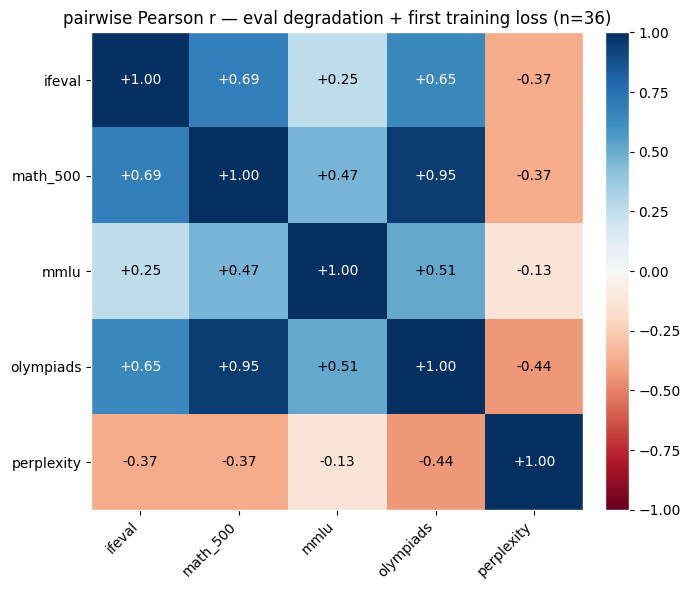

In [12]:
def load_degradation(eval_name, student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]

def load_perplexity(student, teacher):
    path = RUN_DIR / f'student_{student}_teacher_{teacher}' / 'metadata.json'
    metadata = json.load(open(path))
    return metadata['starting_perplexity']


pairs = [(s, t) for s in MODELS for t in MODELS]
rows = EVALS + ['perplexity']
deg = np.array([
    [load_degradation(e, s, t) for s, t in pairs] for e in EVALS
] + [
    [load_perplexity(s, t) for s, t in pairs]
])

mask = ~np.isnan(deg).any(axis=0)
corr = np.corrcoef(deg[:, mask])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(rows)), rows, rotation=45, ha='right')
ax.set_yticks(range(len(rows)), rows)
ax.set_title(f'pairwise Pearson r — eval degradation + first training loss (n={mask.sum()})')
ax.grid(False)
for i in range(len(rows)):
    for j in range(len(rows)):
        v = corr[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.6 else 'black', fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Inoculation Prompting

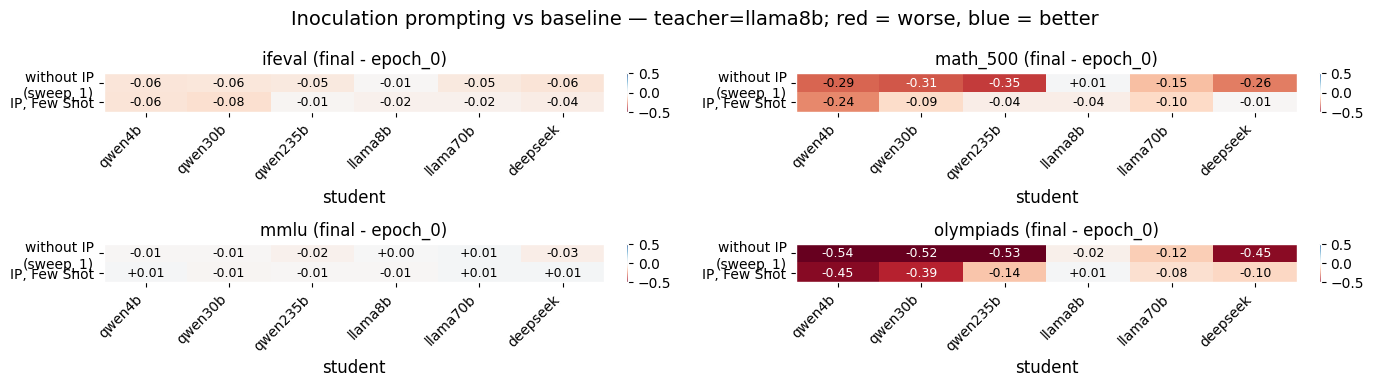

In [4]:
SWEEP_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

# Each entry: (row_label, run_dir, dirname_pattern with {student} placeholder)
IP_RUNS = [
    # ip true
    ('IP, Few Shot',
     Path('/workspace/when-does-sft-degrade-capabilities/runs/llama_ip'),
    'student_{student}_teacher_llama8b_ip')
    # # ip_user_assistant
    # ('IP, user/assistant turns',
    #  Path('/workspace/when-does-sft-degrade-capabilities/runs/ip_user_assistant'),
    #  'student_{student}_teacher_8b_ip_user_assistant'),
]


def load_degradation(run_dir, dirname, eval_name):
    path = run_dir / dirname / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


VLIM = 0.5
baseline = ('without IP\n(sweep_1)', SWEEP_RUN_DIR, 'student_{student}_teacher_llama8b')
all_runs = [baseline] + IP_RUNS
row_labels = [label for label, _, _ in all_runs]

fig, axes = plt.subplots(2, 2, figsize=(14, 1.5 + 1.2 * len(all_runs)))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([
        [load_degradation(rd, pat.format(student=s), eval_name) for s in STUDENTS]
        for _, rd, pat in all_runs
    ])

    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(STUDENTS)), STUDENTS, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel('student')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Inoculation prompting vs baseline — teacher=llama8b; red = worse, blue = better')
fig.tight_layout()
plt.show()

## Numbers

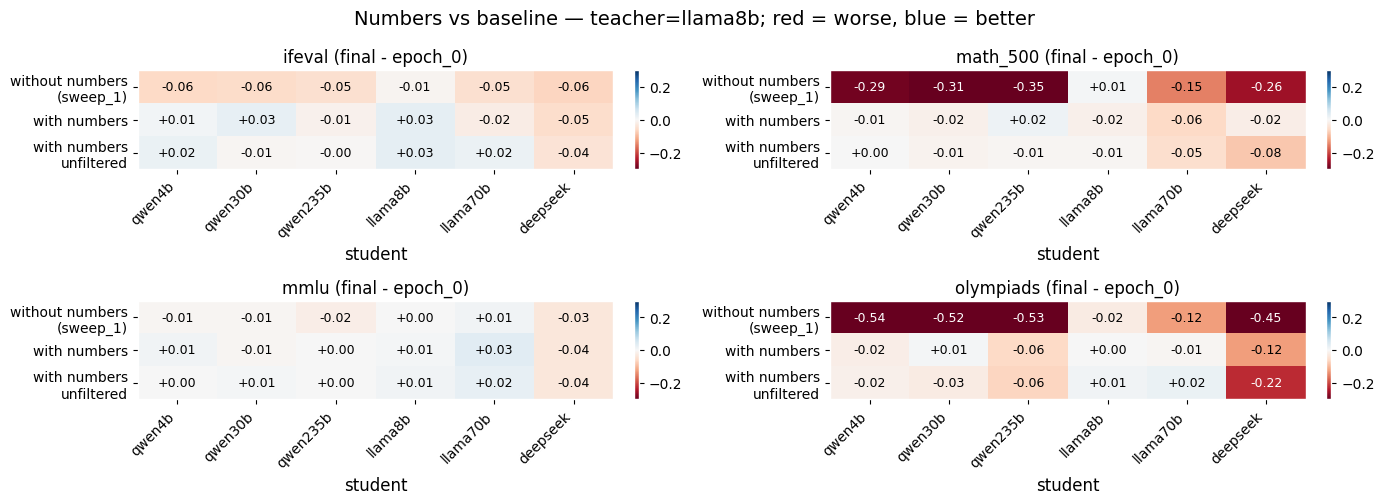

In [5]:
SWEEP_RUN_DIR = Path('/workspace/when-does-sft-degrade-capabilities/runs/sweep_1')
STUDENTS = ['qwen4b', 'qwen30b', 'qwen235b', 'llama8b', 'llama70b', 'deepseek']
EVALS = ['ifeval', 'math_500', 'mmlu', 'olympiads']

# Each entry: (row_label, run_dir, dirname_pattern with {student} placeholder)
NUMBERS_RUNS = [
    ('with numbers',
     Path('/workspace/when-does-sft-degrade-capabilities/runs/numbers'),
     'student_{student}_teacher_llama8b_numbers'),
    ('with numbers\nunfiltered',
     Path('/workspace/when-does-sft-degrade-capabilities/runs/numbers_unfiltered'),
     'student_{student}_teacher_llama8b_numbers'),
]


def load_degradation(run_dir, dirname, eval_name):
    path = run_dir / dirname / 'metadata.json'
    if not path.exists():
        return np.nan
    scores = json.loads(path.read_text())[eval_name]
    return scores[-1] - scores[0]


VLIM = 0.3
baseline = ('without numbers\n(sweep_1)', SWEEP_RUN_DIR, 'student_{student}_teacher_llama8b')
all_runs = [baseline] + NUMBERS_RUNS
row_labels = [label for label, _, _ in all_runs]

fig, axes = plt.subplots(2, 2, figsize=(14, 1.5 + 1.2 * len(all_runs)))
for ax, eval_name in zip(axes.flat, EVALS):
    grid = np.array([
        [load_degradation(rd, pat.format(student=s), eval_name) for s in STUDENTS]
        for _, rd, pat in all_runs
    ])

    im = ax.imshow(grid, cmap='RdBu', vmin=-VLIM, vmax=VLIM, aspect='auto')
    ax.set_xticks(range(len(STUDENTS)), STUDENTS, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel('student')
    ax.set_title(f'{eval_name} (final - epoch_0)')
    ax.grid(False)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.6 * VLIM else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Numbers vs baseline — teacher=llama8b; red = worse, blue = better')
fig.tight_layout()
plt.show()